In [1]:
import kagglehub

path = kagglehub.dataset_download("rumethsandinu/neobreath-pet")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'neobreath-pet' dataset.
Path to dataset files: /kaggle/input/neobreath-pet


In [2]:
import torch

In [3]:
CONFIG = {
    'data_dir': '/kaggle/input/neobreath-pet/PET/up_threshold_0.7',

    # A: Adenocarcinoma, B: Small Cell Carcinoma, G: Squamous Cell Carcinoma
    'classes': ['A', 'B', 'G'],
    'image_size': 128,
    'seq_length': 8,
    'grad_accum': 1,

    # cascaded diffusion
    'cascaded': True,
    'cascade_sizes': [64, 128],  # low-res then high-res

    'epochs': 20,
     # epochs without val loss improvement before stop
    'patience': 20,
    'batch_size': 16,
    'lr': 2e-4,
    'weight_decay': 0.01,
    'save_every': 5,
    'eval_every': 1,

    # DDPM sampling steps (fast) for periodic eval
    'inference_steps': 50,

    # model architecture
    'channels': (64, 128, 256),
    'timesteps': 1000,
    'prediction_type': 'v_prediction',
    'use_fp16': True,

    # EMA
    'ema_decay': 0.999,
    'ema_start': 5,

    # load last checkpoint
    'last_ckpt': None
}

# device detection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print('\nConfigurations:')
    print(f"Image size: {CONFIG['image_size']}×{CONFIG['image_size']}")
    print(f"Sequence length: {CONFIG['seq_length']} frames")
    print(f"Batch size: {CONFIG['batch_size']} (per forward pass)")
    print(f"Effective batch size: {CONFIG['batch_size'] * CONFIG['grad_accum']}")
    print(f"Model channels: {CONFIG['channels']}")
    est_mb = (CONFIG['batch_size'] * CONFIG['seq_length'] * CONFIG['image_size'] * CONFIG['image_size'] * 2 / 1e6)
    print(f"Approx input activations per batch (fp16): ~{est_mb:.1f} MB")
else:
    print("No GPU detected")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.2 GB

Configurations:
Image size: 128×128
Sequence length: 8 frames
Batch size: 16 (per forward pass)
Effective batch size: 16
Model channels: (64, 128, 256)
Approx input activations per batch (fp16): ~4.2 MB


In [4]:
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import InterpolationMode
from pathlib import Path
import torchvision.transforms.functional as TF

# set reproducability
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
class PETDataset(Dataset):
    """
    Custom Dataset for loading PET slice sequences with slice-wise data augmentation.

    Steps:
    1. Splits volumes into fixed-length (seq_len) sequences.
    2. Optionally creates an augmented copy of each full sequence by applying
       conservative, medically-aware augmentations slice-wise.
    3. Resizes to target image_size and returns tensors normalized to [-1, 1]
       ready for a class-conditional DDPM.

    Args:
        data_dir (str or Path): Directory with class subfolders containing .npy files.
        classes (list[str]): List of class folder names (e.g. ['A','B','G']).
        seq_len (int): Number of slices per sequence (default: 8).
        image_size (int): Target H=W for training (default: 200).
        augment (bool): Whether to create augmented copies (default: True).
        augment_times (int): How many augmented copies to create per sequence.
    """

    def __init__(self, data_dir, classes, seq_len=8, image_size=128, augment=True, augment_times=1):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.seq_len = int(seq_len)
        self.image_size = int(image_size)
        self.augment = bool(augment)
        self.augment_times = max(1, int(augment_times))

        # store sequences
        self.sequences = []
        self.skipped_seq = 0

        # load all sequences
        for cls in classes:
            cls_dir = self.data_dir / cls
            if not cls_dir.exists():
                print(f'Data directory for {cls} does not exist')
                continue

            for npy_file in sorted(cls_dir.glob("*.npy")):
                # shape (N, H, W) in range [0, 1]
                vol = np.load(npy_file)

                # only take seq_len chunks. Discard what remains.
                # no padding to train the model for original data.
                n_full = vol.shape[0] // self.seq_len
                if n_full == 0:
                    continue

                for i in range(n_full):
                    start = i * self.seq_len
                    chunk = vol[start:start + self.seq_len]

                    # defensive check: ensure correct shape
                    if chunk.shape[0] != self.seq_len:
                        continue

                    # store original (non-augmented)
                    self.sequences.append((chunk.astype(np.float32), self.class_to_idx[cls], False))

                    # optionally create augmented copies (slice-wise augmentation)
                    if self.augment:
                        for _ in range(self.augment_times):
                            aug_chunk = np.stack([self._augment_slice(s) for s in chunk])
                            self.sequences.append((aug_chunk.astype(np.float32), self.class_to_idx[cls], True))

        # print simple dataset stats for quick verification
        total = len(self.sequences)
        print(f"Loaded {total} sequences (including augmented copies)")
        for cls in classes:
            count = sum(1 for _, lbl, _ in self.sequences if lbl == self.class_to_idx[cls])
            pct = (count/total*100) if total else 0
            print(f"Class {cls}: {count} sequences ({pct:.1f}%)")

    def _augment_slice(self, slice_np):
        """
        Apply conservative, medically-aware augmentations to a single 2D slice.

        Augmentations (~50% probability):
          1. Horizontal flip
          2. Vertical flip
          3. Small rotation (±10 degrees)
          4. Small brightness scaling (0.9 - 1.1)

        Geometric deformation that changes voxel spacing is avoided.
        """

        t = torch.from_numpy(slice_np).unsqueeze(0)

        # horizontal flip
        if random.random() > 0.5:
            t = TF.hflip(t)

        # vertical flip
        if random.random() > 0.5:
            t = TF.vflip(t)

        # rotation ±10 degrees
        if random.random() > 0.5:
            angle = random.uniform(-10, 10)
            t = TF.rotate(t, angle, interpolation=InterpolationMode.BILINEAR)

        # brightness adjust 0.9 - 1.1
        if random.random() > 0.5:
            factor = random.uniform(0.9, 1.1)
            t = TF.adjust_brightness(t, factor)

        out = t.squeeze(0).numpy()

        # clip back to [0,1] in case small numerical excursions occurred
        out = np.clip(out, 0.0, 1.0)
        return out

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq, cls_idx, is_aug = self.sequences[idx]

        # normalize to [-1, 1] (DDPM input convention)
        seq = seq.astype(np.float32) * 2.0 - 1.0

        # convert to PyTorch tensor with channel dim: (seq_len, 1, H, W)
        tensor_seq = torch.from_numpy(seq).unsqueeze(1)

        # resize if needed to (T, 1, image_size, image_size)
        _, _, H, W = tensor_seq.shape
        if (H, W) != (self.image_size, self.image_size):
            tensor_seq = torch.nn.functional.interpolate(
                tensor_seq, size=(self.image_size, self.image_size), mode='bilinear', align_corners=False
            )

        return tensor_seq, torch.tensor(cls_idx, dtype=torch.long)


dataset = PETDataset(
    data_dir=CONFIG['data_dir'],
    classes=CONFIG['classes'],
    seq_len=CONFIG['seq_length'],
    image_size=CONFIG['image_size'],
    augment=True,
    augment_times=1
)

dataloader = DataLoader(
    dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False,
    persistent_workers=False
)

print(f"\nAugmentation Technique: {'Enabled (slice-wise)' if dataset.augment else 'Disabled'}")

Loaded 4178 sequences (including augmented copies)
Class A: 3154 sequences (75.5%)
Class B: 290 sequences (6.9%)
Class G: 734 sequences (17.6%)

Augmentation Technique: Enabled (slice-wise)


In [6]:
import matplotlib.pyplot as plt
import json
from torch.utils.data import Subset, DataLoader as _DL

In [7]:
# train/test split after augmentation with balanced sampling capability

idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
cls_to_indices = {c: [] for c in range(len(CONFIG['classes']))}
for idx, (_seq, lbl, _is_aug) in enumerate(dataset.sequences):
    cls_to_indices[int(lbl)].append(idx)

train_indices, test_indices = [], []
class_split_counts = {}
for cls_idx, idx_list in cls_to_indices.items():
    shuffled = idx_list[:]
    random.shuffle(shuffled)
    n = len(shuffled)
    n_train = int(round(0.8 * n))
    n_train = min(max(0, n_train), max(0, n - 1)) if n > 1 else n
    tr = shuffled[:n_train]
    te = shuffled[n_train:]
    train_indices.extend(tr)
    test_indices.extend(te)
    class_split_counts[idx_to_class[cls_idx]] = {"total": n, "train": len(tr), "test": len(te)}

from torch.utils.data import Subset, WeightedRandomSampler
train_dataset = Subset(dataset, sorted(train_indices))
test_dataset = Subset(dataset, sorted(test_indices))

# compute class weights inverse to frequency for balanced sampling
train_labels = []
for local_idx in train_dataset.indices:
    _, lbl, _ = dataset.sequences[local_idx]
    train_labels.append(int(lbl))
class_counts = np.bincount(train_labels, minlength=len(CONFIG['classes']))
class_weights = 1.0 / (class_counts + 1e-6)
weights = [class_weights[lbl] for lbl in train_labels]

sampler = WeightedRandomSampler(weights, num_samples=len(train_labels), replacement=True)

train_dataloader = _DL(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    sampler=sampler,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False,
    persistent_workers=False
)

test_dataloader = _DL(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False,
    persistent_workers=False
)

print("Split summary (after augmentation):")
import json
print(json.dumps(class_split_counts, indent=2))
print(f"Train sequences: {len(train_dataset)} | Test sequences: {len(test_dataset)} | Total: {len(dataset)}")
print("Class counts (train):", class_counts.tolist())
print("Class weights:", [round(w, 4) for w in class_weights.tolist()])

split_path = 'split_seed42_aug_80_20_balanced.json'
with open(split_path, 'w') as f:
    json.dump({
        "seed": 42,
        "rule": "per-class 80/20 after augmentation + weighted sampler",
        "class_counts": class_split_counts,
        "train_indices": sorted(train_indices),
        "test_indices": sorted(test_indices),
        "class_weights": class_weights.tolist(),
    }, f, indent=2)
print(f"Saved split file: {split_path}")

Split summary (after augmentation):
{
  "A": {
    "total": 3154,
    "train": 2523,
    "test": 631
  },
  "B": {
    "total": 290,
    "train": 232,
    "test": 58
  },
  "G": {
    "total": 734,
    "train": 587,
    "test": 147
  }
}
Train sequences: 3342 | Test sequences: 836 | Total: 4178
Class counts (train): [2523, 232, 587]
Class weights: [0.0004, 0.0043, 0.0017]
Saved split file: split_seed42_aug_80_20_balanced.json


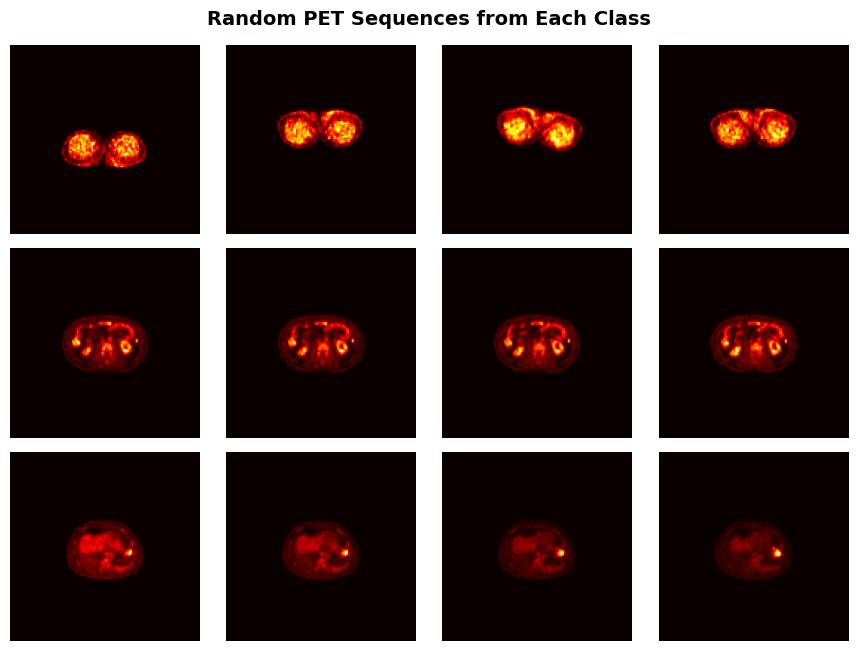

In [8]:
# pick one random sequence per class
samples = []
slices_per_seq = 4
for cls_idx, cls in enumerate(CONFIG['classes']):

    # find indices of this class
    indices = [i for i, (_, lbl, _) in enumerate(dataset.sequences) if lbl == cls_idx]
    if len(indices) == 0:
        print(f"No samples found for class {cls}")
        continue
    idx = random.choice(indices)
    seq, label = dataset[idx]
    samples.append((cls, seq[0: slices_per_seq]))

# visualize
n_rows = len(samples)
n_cols = slices_per_seq
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.2 * n_rows), squeeze=False)

for r, (cls, seq) in enumerate(samples):
    seq = (seq.squeeze(1) + 1) / 2  # [-1,1] → [0,1]
    for c in range(slices_per_seq):
        axes[r, c].imshow(seq[c], cmap='hot')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(cls, fontsize=12, fontweight='bold')

plt.suptitle("Random PET Sequences from Each Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plot_path = f"preprocssed_pet_sequences.jpg"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

In [9]:
from diffusers import UNet2DModel, DDPMScheduler

In [10]:
# Cascaded UNet2D Models (64 -> 128) with simple conditioning
low_size, high_size = CONFIG['cascade_sizes'] if CONFIG.get('cascaded', False) else (CONFIG['image_size'], CONFIG['image_size'])

# low-res generator (1-channel)
model_low = UNet2DModel(
    sample_size=low_size,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=CONFIG['channels'],
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
    class_embed_type="timestep",
    num_class_embeds=len(CONFIG['classes']),
).to(device)

# high-res refiner conditioned on upsampled low-res (concat channel)
model_high = UNet2DModel(
    sample_size=high_size,

    # [noisy_high, upsampled_low]
    in_channels=2,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=CONFIG['channels'],
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
    class_embed_type="timestep",
    num_class_embeds=len(CONFIG['classes']),
).to(device)

# DDPM Schedulers (cosine + v-prediction)
sched_low = DDPMScheduler(
    num_train_timesteps=CONFIG['timesteps'],
    beta_schedule="squaredcos_cap_v2",
    prediction_type=CONFIG['prediction_type']
)
sched_high = DDPMScheduler(
    num_train_timesteps=CONFIG['timesteps'],
    beta_schedule="squaredcos_cap_v2",
    prediction_type=CONFIG['prediction_type']
)

# optimizers
optimizer_low = torch.optim.AdamW(
    model_low.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'], betas=(0.9, 0.999)
)
optimizer_high = torch.optim.AdamW(
    model_high.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'], betas=(0.9, 0.999)
)

# model stats
def _params_stats(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return trainable, total * 2 / 1e6

t_low, mb_low = _params_stats(model_low)
t_high, mb_high = _params_stats(model_high)
print(f"Stage 1 (low {low_size}): trainable={t_low/1e6:.2f}M, ~{mb_low:.1f} MB fp16")
print(f"Stage 2 (high {high_size}): trainable={t_high/1e6:.2f}M, ~{mb_high:.1f} MB fp16")

Stage 1 (low 64): trainable=14.82M, ~29.6 MB fp16
Stage 2 (high 128): trainable=14.82M, ~29.6 MB fp16


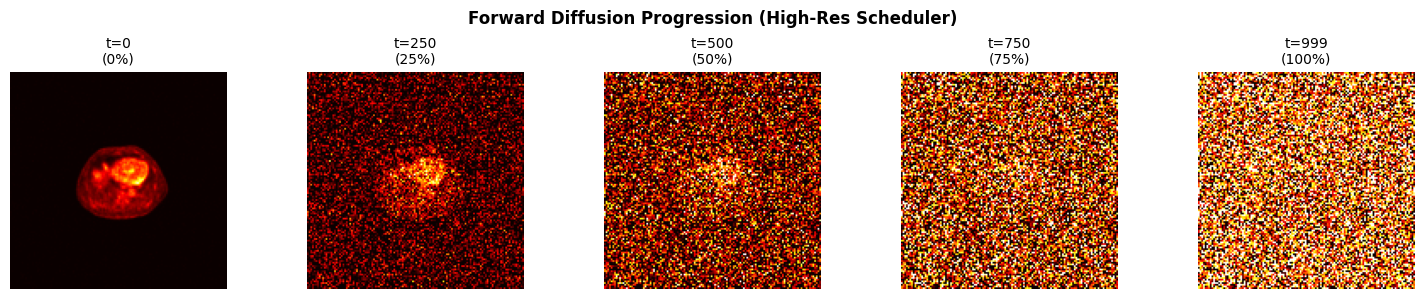

Saved noise progression figure (noise_progression.jpg) and tensor (noise_progression.pt)


In [11]:
# forward diffusion noise progression visualization (high-res scheduler)
import matplotlib.pyplot as plt

try:
    first_batch = next(iter(train_dataloader))
    seqs, labels = first_batch
except StopIteration:
    raise RuntimeError("Train dataloader is empty – cannot visualize noise progression.")

# select first sequence's first frame (channel already 1) in [-1,1]
img0 = seqs[0, 0].unsqueeze(0).to(device)  # (1,1,H,W)

# fixed noise for reproducibility
noise = torch.randn_like(img0)

T = int(CONFIG['timesteps'])
# pick 5 representative timesteps: 0, 25, 50, 75, 100
show_ts = [0, T//4, T//2, 3*T//4, T-1]
show_ts = sorted(set(show_ts))

noised_imgs = []
with torch.no_grad():
    for t in show_ts:
        ts = torch.tensor([t], dtype=torch.long, device=device)
        xt = sched_high.add_noise(img0, noise, ts)  # q(x_t|x_0) using high-res scheduler
        noised_imgs.append(xt.squeeze(0).detach().cpu())  # (1,H,W)

# plot
num_cols = len(noised_imgs)
fig, axes = plt.subplots(1, num_cols, figsize=(3 * num_cols, 3), squeeze=False)
for i, (t, x_t) in enumerate(zip(show_ts, noised_imgs)):
    vis = (x_t + 1) / 2  # map [-1,1] -> [0,1]
    vis = vis.clamp(0, 1)
    axes[0, i].imshow(vis[0], cmap='hot', vmin=0, vmax=1)
    axes[0, i].axis('off')
    pct = 100 * t / (T - 1)
    axes[0, i].set_title(f"t={t}\n({pct:.0f}%)", fontsize=10)

plt.suptitle("Forward Diffusion Progression (High-Res Scheduler)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('noise_progression.jpg', dpi=150, bbox_inches='tight')
plt.show()

# optionally store tensor stack for later analysis
progress_tensor = torch.stack(noised_imgs)  # (len(show_ts), 1, H, W)
torch.save({'timesteps': show_ts, 'samples': progress_tensor}, 'noise_progression.pt')
print("Saved noise progression figure (noise_progression.jpg) and tensor (noise_progression.pt)")

In [12]:
import os

In [13]:
# resume from checkpoint if provided and dry-run forward pass ---
start_epoch = 0

if CONFIG.get('last_ckpt'):
    ckpt_path = str(CONFIG['last_ckpt'])
    if os.path.exists(ckpt_path):
        print(f"Checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)

        # load model and optimizer states if present
        if isinstance(ckpt, dict):
            if 'model' in ckpt:
                model.load_state_dict(ckpt['model'])
                print("Loaded model state_dict.")
            if 'optimizer' in ckpt:
                try:
                    optimizer.load_state_dict(ckpt['optimizer'])
                    print("Loaded optimizer state_dict.")
                except Exception as e:
                    print(f"Warning: could not load optimizer state: {e}")
            if 'ema' in ckpt and isinstance(ckpt['ema'], dict):
                ema.shadow = ckpt['ema']
                print("Loaded EMA shadow weights.")
            if 'epoch' in ckpt:
                start_epoch = int(ckpt['epoch'])
                print(f"Resuming from epoch index {start_epoch}.")
            if 'loss' in ckpt:
                resume_last_loss = float(ckpt['loss'])
        else:
            print("Unexpected checkpoint format (expected dict). Proceeding without resume.")

        # dry-run forward pass (no grad) to verify shapes without updating gradients
        try:
            model.eval()
            with torch.no_grad():
                try:
                    batch = next(iter(train_dataloader))
                    seqs, labels = batch
                    B, T, C, H, W = seqs.shape
                    imgs = seqs.view(-1, C, H, W).to(device)
                    labels_flat = labels.unsqueeze(1).repeat(1, T).view(-1).to(device)
                except Exception:
                    # fallback to synthetic input
                    B = max(1, int(CONFIG.get('batch_size', 1)))
                    T = int(CONFIG.get('seq_length', 8))
                    H = W = int(CONFIG.get('image_size', 200))
                    imgs = torch.randn(B*T, 1, H, W, device=device)
                    labels_flat = torch.zeros(B*T, dtype=torch.long, device=device)

                noise = torch.randn_like(imgs)
                timesteps = torch.randint(0, CONFIG['timesteps'], (imgs.shape[0],), device=device)
                noisy = scheduler.add_noise(imgs, noise, timesteps)

                out = model(noisy, timesteps, class_labels=labels_flat)
                print(f"Dry-run forward: output.sample shape = {tuple(out.sample.shape)}")
        except Exception as e:
            print(f"Dry-run forward failed: {e}")
        finally:
            model.train()
    else:
        print(f"Configured last_ckpt not found: {ckpt_path}")
else:
    print("No last_ckpt configured. Starting from scratch.")

No last_ckpt configured. Starting from scratch.


In [14]:
import gc

In [15]:
if torch.cuda.is_available():

    # clear cached memory
    torch.cuda.empty_cache()
    gc.collect()

    # check current GPU memory usage
    allocated = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    available = total - allocated

    print(f"Allocated: {allocated:.2f} GB")
    print(f"Available: {available:.2f} GB")

else:
    print("No GPU detected — training will run on CPU")

Allocated: 0.12 GB
Available: 85.05 GB


In [16]:
from torch.amp import autocast

In [17]:
# exponential Moving Average (EMA) for better sample fidelity
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = float(decay)
        self.shadow = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.detach().clone()

    @torch.no_grad()
    def update(self, model):
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            new_average = (1.0 - self.decay) * param.detach() + self.decay * self.shadow[name]
            self.shadow[name] = new_average.clone()

    @torch.no_grad()
    def copy_to(self, model):
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            param.data.copy_(self.shadow[name].data)

# create EMA wrappers for both stages
epochs_before_ema = int(CONFIG['ema_start'])
ema_low = EMA(model_low, decay=CONFIG['ema_decay'])
ema_high = EMA(model_high, decay=CONFIG['ema_decay'])


In [18]:
def generate_cascaded(model_low, model_high, sched_low, sched_high, class_idx, n_samples=4, n_frames=8, use_ema=True):
    """
    Two-stage cascaded generation:
      1) Generate low-res frames with model_low
      2) Upsample and refine with model_high conditioned on the low-res
    Returns (n_samples, n_frames, 1, high_size, high_size) in [-1, 1].
    """
    low_size, high_size = CONFIG['cascade_sizes']
    model_low.eval(); model_high.eval()
    start_time = time.time()

    # optionally copy EMA weights
    st_low = {k: v.detach().clone() for k, v in model_low.state_dict().items()} if use_ema else None
    st_high = {k: v.detach().clone() for k, v in model_high.state_dict().items()} if use_ema else None
    if use_ema:
        ema_low.copy_to(model_low)
        ema_high.copy_to(model_high)

    with torch.no_grad():
        total = n_samples * n_frames
        labels = torch.full((total,), class_idx, device=device, dtype=torch.long)

        # stage 1: low-res sampling
        x_low = torch.randn(total, 1, low_size, low_size, device=device)
        sched_low.set_timesteps(CONFIG['inference_steps'])
        for t in tqdm(sched_low.timesteps, desc=f"Cascade Stage1 {CONFIG['classes'][class_idx]}", leave=True):
            ts = torch.full((total,), t, device=device, dtype=torch.long)
            with autocast(device_type=device.type, enabled=CONFIG['use_fp16']):
                pred = model_low(x_low, ts, class_labels=labels).sample
            x_low = sched_low.step(pred, t, x_low).prev_sample

        # ipsample low-res (nearest/bilinear) to high-res for conditioning
        x_low_up = torch.nn.functional.interpolate(x_low, size=(high_size, high_size), mode='bilinear', align_corners=False)

        # stage 2: high-res sampling conditioned on upsampled low-res
        x_high = torch.randn(total, 1, high_size, high_size, device=device)
        sched_high.set_timesteps(CONFIG['inference_steps'])
        for t in tqdm(sched_high.timesteps, desc=f"Cascade Stage2 {CONFIG['classes'][class_idx]}", leave=True):
            ts = torch.full((total,), t, device=device, dtype=torch.long)

            # concat noisy high-res and upsampled low-res as 2 channels
            x_in = torch.cat([x_high, x_low_up], dim=1)
            with autocast(device_type=device.type, enabled=CONFIG['use_fp16']):
                pred = model_high(x_in, ts, class_labels=labels).sample

            # scheduler expects the current noisy sample (first channel)
            x_high = sched_high.step(pred, t, x_high).prev_sample

    # restore weights
    if use_ema and st_low is not None:
        model_low.load_state_dict(st_low)
    if use_ema and st_high is not None:
        model_high.load_state_dict(st_high)

    if device.type == 'cuda':
        torch.cuda.empty_cache()
    print(f"Cascaded generation for '{CONFIG['classes'][class_idx]}' in {(time.time() - start_time)/60:.1f} min")

    return x_high.view(n_samples, n_frames, 1, high_size, high_size)

In [19]:
from torch.amp import GradScaler
import time
from tqdm import tqdm
import torch.nn.functional as F

# metrics: diversity, SSIM, pixel_diff (MAE)
import math
import torch
import torch.nn.functional as F

try:
    from skimage.metrics import structural_similarity as skimage_ssim
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False


def _to_01(x: torch.Tensor) -> torch.Tensor:
    """Ensure tensor image(s) are in [0,1]. Input can be [-1,1] or [0,1].
    Accepts shapes (N, H, W) or (N, 1, H, W) or (H, W). Returns float32 on CPU.
    """
    if isinstance(x, torch.Tensor):
        t = x.detach()
    else:
        t = torch.as_tensor(x)
    t = t.float()
    # squeeze channel if single
    if t.ndim == 4 and t.size(1) == 1:
        t = t.squeeze(1)
    # map from [-1,1] -> [0,1] if clearly outside [0,1]
    tmin, tmax = t.min().item(), t.max().item()
    if tmin < -0.2 or tmax > 1.2:
        t = (t + 1.0) / 2.0
    return t.clamp(0.0, 1.0).cpu()


def compute_diversity(gen_imgs: torch.Tensor) -> float:
    """Average pairwise L1 distance in pixel space, normalized to [0,1].
    gen_imgs: (N, H, W) or (N, 1, H, W) or (N, C=1, H, W)
    Returns a scalar float.
    """
    x = _to_01(gen_imgs)  # (N, H, W)
    # single image -> no diversity
    if x.ndim == 2:
        return 0.0
    N = x.shape[0]
    if N < 2:
        return 0.0
    H, W = x.shape[-2], x.shape[-1]
    flat = x.view(N, -1)  # (N, H*W)

    # pairwise L1 distances; use cdist with p=1 for simplicity
    with torch.no_grad():
        dists = torch.cdist(flat, flat, p=1)

        # exclude diagonal and duplicates by taking upper triangle only
        iu = torch.triu_indices(N, N, offset=1)
        mean_l1 = dists[iu[0], iu[1]].mean().item()

        # normalize by number of pixels (max L1 per pair in [0,1] space is H*W)
        norm = float(H * W)
        return float(mean_l1 / (norm + 1e-8))


# minimal torch SSIM fallback (single-channel, 2D)
def _torch_ssim(img1: torch.Tensor, img2: torch.Tensor) -> float:
    # expects (H, W) in [0,1]
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    x = img1.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
    y = img2.unsqueeze(0).unsqueeze(0)

    # simple 3x3 average window to keep it lightweight
    kernel = torch.ones((1, 1, 3, 3), dtype=x.dtype) / 9.0
    mu_x = F.conv2d(x, kernel, padding=1)
    mu_y = F.conv2d(y, kernel, padding=1)
    mu_x2 = mu_x.pow(2)
    mu_y2 = mu_y.pow(2)
    mu_xy = mu_x * mu_y
    sigma_x2 = F.conv2d(x * x, kernel, padding=1) - mu_x2
    sigma_y2 = F.conv2d(y * y, kernel, padding=1) - mu_y2
    sigma_xy = F.conv2d(x * y, kernel, padding=1) - mu_xy
    ssim_map = ((2 * mu_xy + C1) * (2 * sigma_xy + C2)) / ((mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2) + 1e-8)
    return float(ssim_map.mean().item())


def compute_ssim(gen_imgs: torch.Tensor, real_imgs: torch.Tensor, max_pairs: int = 32) -> float:
    """Mean SSIM between generated and real images.
    Matches up to max_pairs images by random pairing. Inputs in any of (N,H,W),(N,1,H,W).
    Returns mean SSIM in [0,1].
    """
    g = _to_01(gen_imgs)
    r = _to_01(real_imgs)
    Ng, Nr = g.shape[0], r.shape[0]
    if Ng == 0 or Nr == 0:
        return 0.0
    n = int(min(max_pairs, Ng, Nr))

    # deterministic pairing with local generator (no global RNG side-effects)
    ggen = torch.Generator().manual_seed(0)
    rgen = torch.Generator().manual_seed(0)
    idx_g = torch.randperm(Ng, generator=ggen)[:n]
    idx_r = torch.randperm(Nr, generator=rgen)[:n]
    g = g[idx_g]
    r = r[idx_r]
    scores = []
    for i in range(n):
        gi = g[i]
        ri = r[i]
        if _HAS_SKIMAGE:
            try:
                val = skimage_ssim(gi.numpy(), ri.numpy(), data_range=1.0)
            except Exception:
                val = _torch_ssim(gi, ri)
        else:
            val = _torch_ssim(gi, ri)

        # clamp to [0,1]
        scores.append(max(0.0, min(1.0, float(val))))
    return float(sum(scores) / len(scores))


def compute_pixel_diff(gen_imgs: torch.Tensor, real_imgs: torch.Tensor, max_pairs: int = 32) -> float:
    """Mean Absolute Error between generated and real images in [0,1].
    Pairs up to max_pairs images. Returns scalar in [0,1].
    """
    g = _to_01(gen_imgs)
    r = _to_01(real_imgs)
    Ng, Nr = g.shape[0], r.shape[0]
    if Ng == 0 or Nr == 0:
        return 0.0
    n = int(min(max_pairs, Ng, Nr))
    gen = torch.Generator().manual_seed(0)
    idx_g = torch.randperm(Ng, generator=gen)[:n]
    idx_r = torch.randperm(Nr, generator=gen)[:n]
    g = g[idx_g]
    r = r[idx_r]
    with torch.no_grad():
        mae = (g - r).abs().mean().item()
    return float(mae)


In [20]:
scaler = GradScaler(enabled=CONFIG['use_fp16'])
losses = []
best_loss = float('inf')
no_improve = 0

# metrics history
diversity_scores = []
pixel_diffs = []
ssim_scores = []
improvement = []

log_path = "training_log.txt"
if not os.path.exists(log_path):
    with open(log_path, 'w') as f:
        f.write("epoch,loss_low,loss_high,improvement,diversity,pixel_diff,ssim,time_min\n")

# training loop (cascaded): train stage1 on downsampled, stage2 on high-res with conditioning
for epoch in range(start_epoch, CONFIG['epochs']):
    model_low.train(); model_high.train()
    epoch_loss_low = 0.0
    epoch_loss_high = 0.0
    optimizer_low.zero_grad()
    optimizer_high.zero_grad()
    start_time = time.time()

    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}")
    for i, (seqs, labels) in enumerate(pbar):
        B, T, C, H, W = seqs.shape
        imgs_high = seqs.view(-1, C, H, W).to(device)
        labels_flat = labels.unsqueeze(1).repeat(1, T).view(-1).to(device)

        # prepare low-res targets by downsampling clean imgs
        low_size, high_size = CONFIG['cascade_sizes']
        imgs_low = torch.nn.functional.interpolate(imgs_high, size=(low_size, low_size), mode='bilinear', align_corners=False)

        # Stage 1 (low-res)
        noise_low = torch.randn_like(imgs_low)
        t_low = torch.randint(0, CONFIG['timesteps'], (imgs_low.shape[0],), device=device)
        noisy_low = sched_low.add_noise(imgs_low, noise_low, t_low)

        with autocast(device_type=device.type, enabled=CONFIG['use_fp16']):
            out_low = model_low(noisy_low, t_low, class_labels=labels_flat)
            pred_low = out_low.sample
            target_low = sched_low.get_velocity(imgs_low, noise_low, t_low) if CONFIG['prediction_type'] == 'v_prediction' else noise_low
            loss_low = F.mse_loss(pred_low, target_low) / CONFIG['grad_accum']

        scaler.scale(loss_low).backward()

        # Stage 2 (high-res)
        cond_up = torch.nn.functional.interpolate(imgs_low, size=(high_size, high_size), mode='bilinear', align_corners=False)
        noise_high = torch.randn_like(imgs_high)
        t_high = torch.randint(0, CONFIG['timesteps'], (imgs_high.shape[0],), device=device)
        noisy_high = sched_high.add_noise(imgs_high, noise_high, t_high)
        x_in = torch.cat([noisy_high, cond_up], dim=1)

        with autocast(device_type=device.type, enabled=CONFIG['use_fp16']):
            out_high = model_high(x_in, t_high, class_labels=labels_flat)
            pred_high = out_high.sample
            target_high = sched_high.get_velocity(imgs_high, noise_high, t_high) if CONFIG['prediction_type'] == 'v_prediction' else noise_high
            loss_high = F.mse_loss(pred_high, target_high) / CONFIG['grad_accum']

        scaler.scale(loss_high).backward()

        if (i + 1) % CONFIG['grad_accum'] == 0:

            # stage 1 update
            scaler.unscale_(optimizer_low)
            torch.nn.utils.clip_grad_norm_(model_low.parameters(), 1.0)
            scaler.step(optimizer_low)
            # stage 2 update
            scaler.unscale_(optimizer_high)
            torch.nn.utils.clip_grad_norm_(model_high.parameters(), 1.0)
            scaler.step(optimizer_high)
            scaler.update()
            optimizer_low.zero_grad()
            optimizer_high.zero_grad()

            # EMA after warmup
            if (epoch + 1) >= CONFIG['ema_start']:
                ema_low.update(model_low)
                ema_high.update(model_high)

        epoch_loss_low += loss_low.item() * CONFIG['grad_accum']
        epoch_loss_high += loss_high.item() * CONFIG['grad_accum']
        pbar.set_postfix({'loss_low': f'{loss_low.item()*CONFIG["grad_accum"]:.4f}', 'loss_high': f'{loss_high.item()*CONFIG["grad_accum"]:.4f}'})

    avg_loss_low = epoch_loss_low / max(1, len(train_dataloader))
    avg_loss_high = epoch_loss_high / max(1, len(train_dataloader))
    avg_loss = (avg_loss_low + avg_loss_high) / 2.0
    losses.append(avg_loss)
    elapsed = time.time() - start_time

    # improvement
    if len(losses) < 2:
        improvement.append(0.0)
        no_improve = 0
    else:
        delta = losses[-2] - avg_loss
        improvement.append(delta)
        no_improve = 0 if delta > 0.0 else (no_improve + 1)

    # save best (both stages)
    if avg_loss < best_loss:
        best_loss = avg_loss
        no_improve = 0
        torch.save({
            'model_low': model_low.state_dict(),
            'model_high': model_high.state_dict(),
            'optimizer_low': optimizer_low.state_dict(),
            'optimizer_high': optimizer_high.state_dict(),
            'ema_low': ema_low.shadow,
            'ema_high': ema_high.shadow,
            'loss_low': avg_loss_low,
            'loss_high': avg_loss_high,
            'loss': avg_loss,
            'config': CONFIG,
            'epoch': epoch + 1,
        }, "best.pt")
        print(f"\nBest cascaded model updated: loss_low={avg_loss_low:.4f}, loss_high={avg_loss_high:.4f}")

    # lightweight evaluation
    do_eval = ((epoch + 1) % CONFIG['eval_every'] == 0) or ((epoch + 1) == CONFIG['epochs'])
    if do_eval:
        model_low.eval(); model_high.eval()
        generated = {}
        class_diversity = []
        class_pixel_diff = []
        class_ssim = []

        # collect real images from test
        all_real_imgs = []
        all_real_labels = []
        for rseqs, rlabels in test_dataloader:
            all_real_imgs.append(rseqs)
            all_real_labels.append(rlabels)
        real_seqs = torch.cat(all_real_imgs, dim=0).to(device)
        real_labels = torch.cat(all_real_labels, dim=0).to(device)
        RH, RW = real_seqs.shape[-2], real_seqs.shape[-1]

        with torch.no_grad():
            for cls_idx, cls in enumerate(CONFIG['classes']):
                samples = generate_cascaded(model_low, model_high, sched_low, sched_high,
                                            class_idx=cls_idx,
                                            n_samples=min(4, CONFIG['batch_size']),
                                            n_frames=CONFIG['seq_length'], use_ema=True)
                generated[cls] = samples
                gen_imgs = samples.view(-1, 1, RH, RW)

                div_val = compute_diversity(gen_imgs)
                class_diversity.append(div_val)

                mask = (real_labels == cls_idx)
                real_imgs = real_seqs[mask].view(-1, 1, RH, RW) if mask.sum() > 0 else real_seqs.view(-1, 1, RH, RW)
                pdiff = compute_pixel_diff(gen_imgs, real_imgs)
                ssim_val = compute_ssim(gen_imgs, real_imgs)
                class_pixel_diff.append(pdiff)
                class_ssim.append(ssim_val)

        diversity_scores.append(class_diversity)
        pixel_diffs.append(class_pixel_diff)
        ssim_scores.append(class_ssim)

        print(
            f"Epoch {epoch+1}: loss_low={avg_loss_low:.4f}, loss_high={avg_loss_high:.4f}, "+
            f"improv={improvement[-1]:.4f}, "+
            f"diversity={[round(d,4) for d in class_diversity]}, "+
            f"pixel_diff={[round(p,4) for p in class_pixel_diff]}, "+
            f"ssim={[round(s,4) for s in class_ssim]}, "+
            f"time={elapsed/60:.1f}min"
        )

        with open(log_path, 'a') as f:
            f.write(
                f"{epoch+1},{avg_loss_low:.4f},{avg_loss_high:.4f},{improvement[-1]:.4f},"
                f"{[round(d,4) for d in class_diversity]},"
                f"{[round(p,4) for p in class_pixel_diff]},"
                f"{[round(s,4) for s in class_ssim]},{elapsed/60:.2f}\n"
            )

        if (epoch + 1) % CONFIG['save_every'] == 0 or ((epoch + 1) == CONFIG['epochs']):
            ckpt_path = f"ckpt_ep{epoch+1}.pt"
            torch.save({
                'epoch': epoch + 1,
                'model_low': model_low.state_dict(),
                'model_high': model_high.state_dict(),
                'optimizer_low': optimizer_low.state_dict(),
                'optimizer_high': optimizer_high.state_dict(),
                'ema_low': ema_low.shadow,
                'ema_high': ema_high.shadow,
                'loss_low': avg_loss_low,
                'loss_high': avg_loss_high,
                'loss': avg_loss,
                'config': CONFIG,
            }, ckpt_path)
            print(f"checkpoint saved: {ckpt_path}")

    # early stopping
    if no_improve >= CONFIG['patience']:
        print(f"Early stopping at epoch {epoch+1} (no improvement for {CONFIG['patience']} epochs).")
        break

print(f"\nFinal losses: low={avg_loss_low:.4f}, high={avg_loss_high:.4f}, Best avg: {best_loss:.4f}")
print(f"Training log saved at: {log_path}")

Epoch 1/20: 100%|██████████| 209/209 [05:04<00:00,  1.46s/it, loss_low=0.0129, loss_high=0.0047]



Best cascaded model updated: loss_low=0.0368, loss_high=0.0353


Cascade Stage2 A: 100%|██████████| 50/50 [00:05<00:00,  9.85it/s]


Cascaded generation for 'A' in 0.1 min


Cascade Stage2 B: 100%|██████████| 50/50 [00:05<00:00,  9.87it/s]


...

Cascaded generation for 'A' in 0.1 min


Cascade Stage2 B: 100%|██████████| 50/50 [00:05<00:00,  9.87it/s]


Cascaded generation for 'B' in 0.1 min


Cascade Stage2 G: 100%|██████████| 50/50 [00:05<00:00,  9.87it/s]


Cascaded generation for 'G' in 0.1 min
Epoch 20: loss_low=0.0087, loss_high=0.0014, improv=-0.0001, diversity=[0.0089, 0.0088, 0.0202], pixel_diff=[0.0134, 0.0167, 0.0218], ssim=[0.6976, 0.6835, 0.6704], time=5.1min
checkpoint saved: ckpt_ep20.pt

Final losses: low=0.0087, high=0.0014, Best avg: 0.0050
Training log saved at: training_log.txt


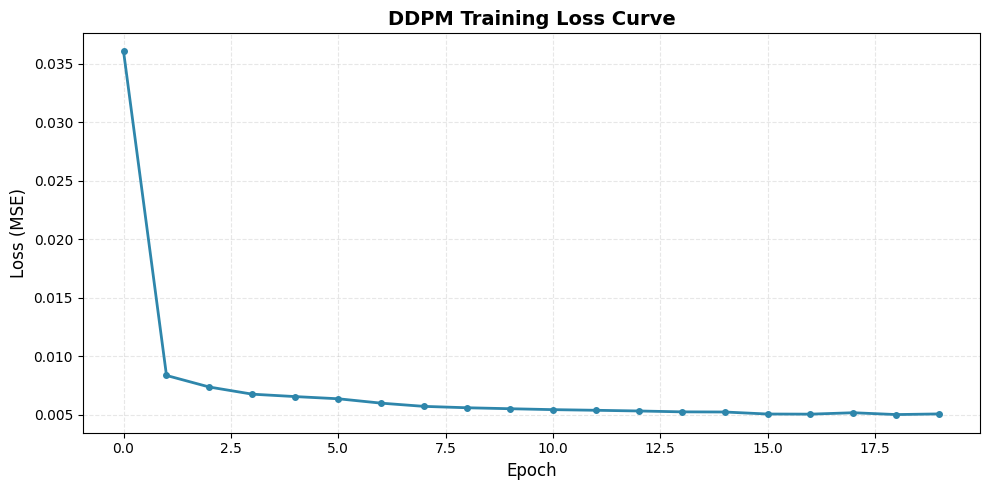

Initial loss: 0.0360
Final loss: 0.0051
Best loss: 0.0050 @ epoch 19
Worst loss: 0.0360 @ epoch 1


In [21]:
# loss curve
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2, color='#2E86AB', marker='o', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('DDPM Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')

plt.show()

# print statistics
print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Best loss: {min(losses):.4f} @ epoch {losses.index(min(losses))+1}")
print(f"Worst loss: {max(losses):.4f} @ epoch {losses.index(max(losses))+1}")

  Class A: torch.Size([8, 128, 128])
  Class B: torch.Size([8, 128, 128])
  Class G: torch.Size([8, 128, 128])


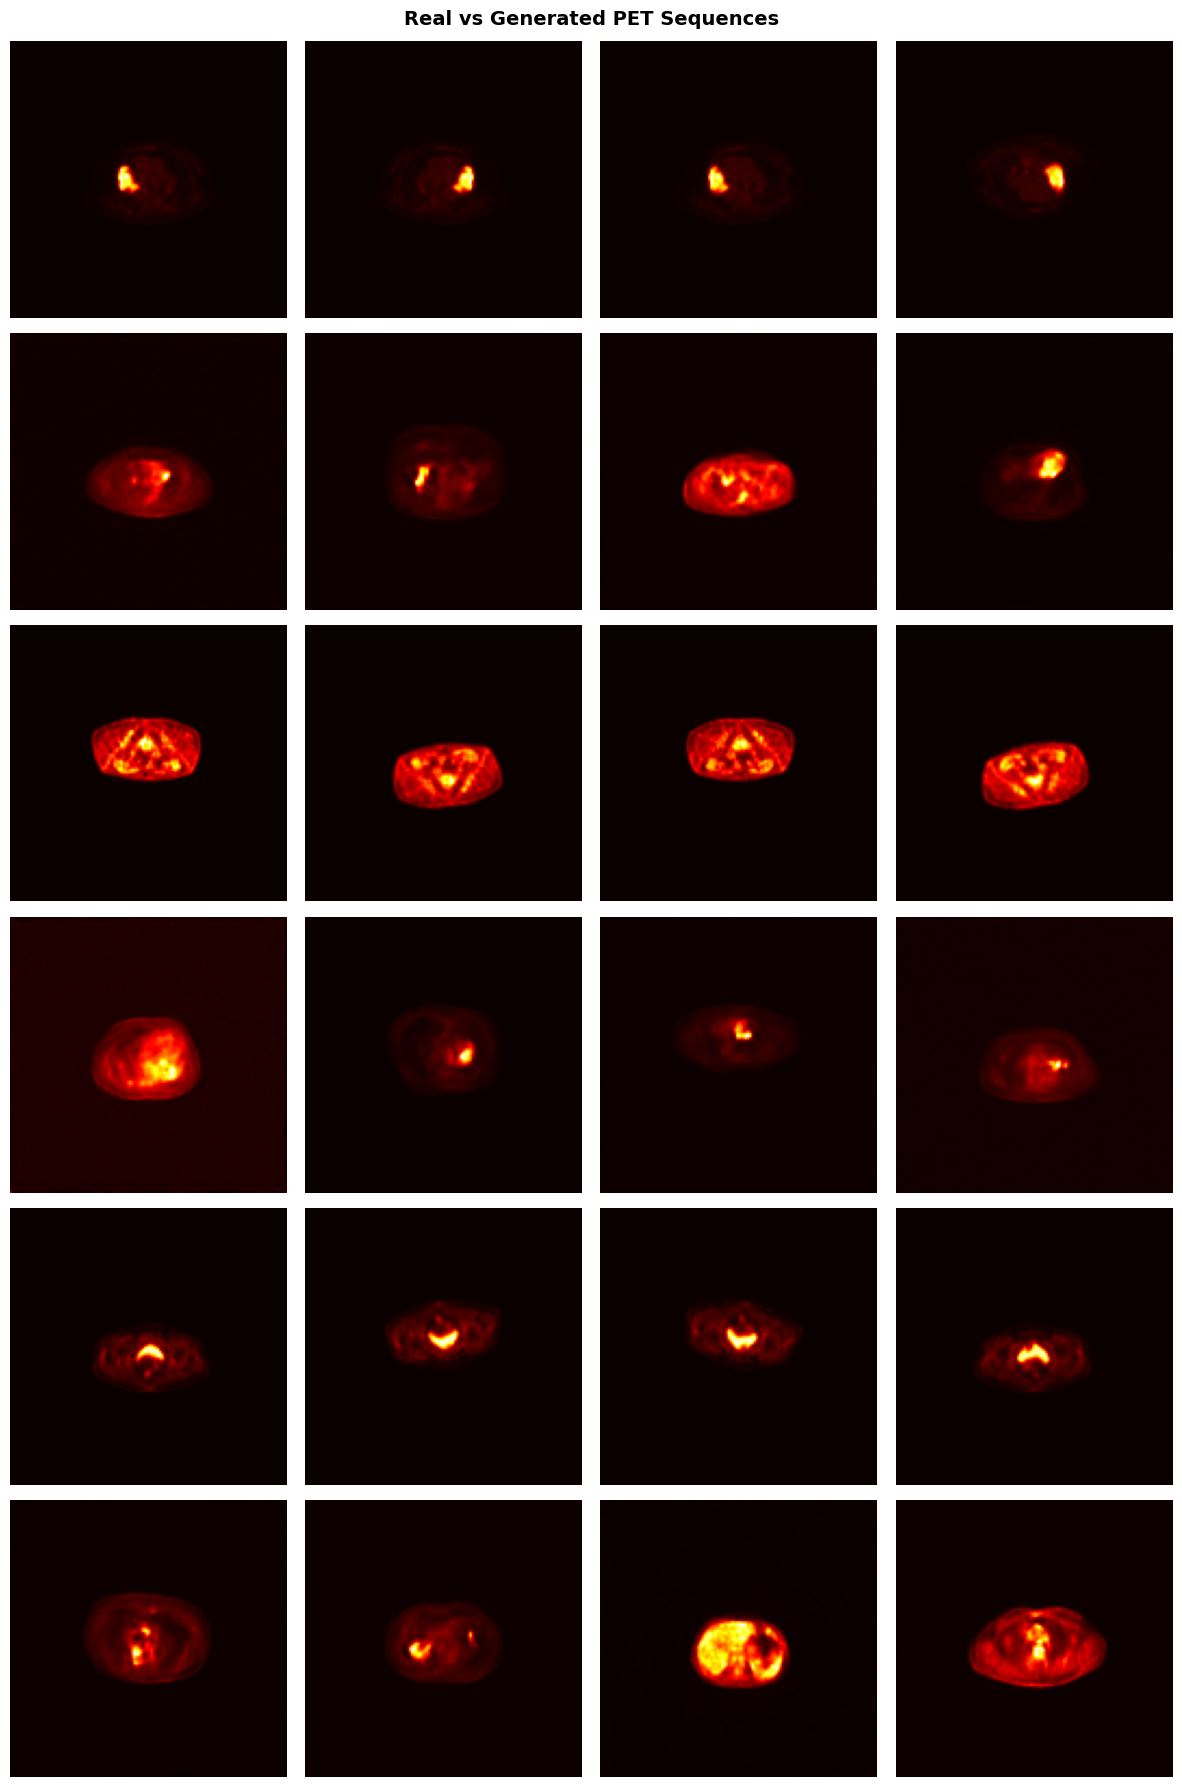

In [22]:
# extract real samples and compare
# load best checkpoint and generate a small batch per class using EMA.
if 'generated' not in globals():
    print("No in-memory generated samples found. Loading best.pt for quick comparison.")
    ck = torch.load('best.pt', map_location=device)
    model.load_state_dict(ck['model'])
    if 'ema' in ck and isinstance(ck['ema'], dict):
        ema.shadow = ck['ema']
    model.eval()
    generated = {}
    with torch.no_grad():
        for cls_idx, cls in enumerate(CONFIG['classes']):
            generated[cls] = generate(model, scheduler, cls_idx, n_samples=1, n_frames=CONFIG['seq_length'], use_ema=True)

# collect some real samples from test set
real = {}
for seqs, labels in test_dataloader:
    for i, cls in enumerate(CONFIG['classes']):
        if cls not in real:
            mask = labels == i
            if mask.any():
                real[cls] = seqs[mask][0].squeeze(1).cpu()
    if len(real) == len(CONFIG['classes']):
        break

for cls in CONFIG['classes']:
    if cls in real:
        print(f"  Class {cls}: {real[cls].shape}")

# plot
n_display = min(4, CONFIG['seq_length'])
fig, axes = plt.subplots(len(CONFIG['classes']) * 2, n_display,
                         figsize=(12, 3 * len(CONFIG['classes']) * 2))

for i, cls in enumerate(CONFIG['classes']):
    # real samples (top row)
    for j in range(n_display):
        img = (real[cls][j].numpy() + 1) / 2
        axes[i * 2, j].imshow(img, cmap='hot')
        axes[i * 2, j].axis('off')
        if j == 0:
            axes[i * 2, j].set_ylabel(f'Real\n{cls}', fontsize=11,
                                      fontweight='bold', rotation=0, labelpad=35)

    # generated samples (bottom row)
    for j in range(n_display):
        img = (generated[cls][0, j].cpu().numpy() + 1) / 2
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]
        axes[i * 2 + 1, j].imshow(img, cmap='hot')
        axes[i * 2 + 1, j].axis('off')
        if j == 0:
            axes[i * 2 + 1, j].set_ylabel(f'Generated\n{cls}', fontsize=11,
                                          fontweight='bold', rotation=0, labelpad=35)

plt.suptitle('Real vs Generated PET Sequences',
             fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('comparison_real_vs_generated.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
def evaluate_generated_sequences(n_sequences: int = 25,
                                 use_ema: bool = True,
                                 save_path: str | None = "eval_25_sequences.json"):
    """
    Generate 'n_sequences' sequences per class and evaluate them against the test data.
    """

    if 'test_dataloader' not in globals():
        print("Test dataloader not available. Run the split/setup cells first.")
        return {}

    # sggregate entire test set into memory for stable class-wise evaluation
    all_real_imgs, all_real_labels = [], []
    for rseqs, rlabels in test_dataloader:
        all_real_imgs.append(rseqs)
        all_real_labels.append(rlabels)

    if len(all_real_imgs) == 0:
        print("Test dataloader is empty — cannot evaluate.")
        return {}

    real_seqs = torch.cat(all_real_imgs, dim=0).to(device)        # (N_seq, T, 1, H, W)
    real_labels = torch.cat(all_real_labels, dim=0).to(device)     # (N_seq,)
    H, W = real_seqs.shape[-2], real_seqs.shape[-1]

    start = time.time()
    per_class = {}

    # ensure eval mode for generation
    model_low.eval(); model_high.eval()

    for cls_idx, cls in enumerate(CONFIG['classes']):
        # generate n_sequences sequences for class 'cls_idx'
        samples = generate_cascaded(
            model_low, model_high, sched_low, sched_high,
            class_idx=cls_idx,
            n_samples=n_sequences,
            n_frames=CONFIG['seq_length'],
            use_ema=use_ema
        )  # (n_sequences, T, 1, H, W) in [-1, 1]

        # flatten sequences to frames for metric computation
        gen_imgs = samples.view(-1, 1, H, W)

        # pick real frames for the same class
        mask = (real_labels == cls_idx)
        real_imgs = real_seqs[mask].view(-1, 1, H, W) if mask.any() else real_seqs.view(-1, 1, H, W)

        # metrics (no cap)
        pairs_n = int(min(gen_imgs.shape[0], real_imgs.shape[0]))
        div_val = compute_diversity(gen_imgs)
        mae_val = compute_pixel_diff(gen_imgs, real_imgs, max_pairs=pairs_n)
        ssim_val = compute_ssim(gen_imgs, real_imgs, max_pairs=pairs_n)

        per_class[cls] = {
            'diversity': float(div_val),
            'pixel_diff': float(mae_val),
            'ssim': float(ssim_val),
            'num_generated_sequences': int(n_sequences),
            'num_generated_frames': int(gen_imgs.shape[0]),
            'num_real_frames_available': int(real_imgs.shape[0])
        }

    # overall means across classes
    overall = {
        'diversity': float(np.mean([v['diversity'] for v in per_class.values()])),
        'pixel_diff': float(np.mean([v['pixel_diff'] for v in per_class.values()])),
        'ssim': float(np.mean([v['ssim'] for v in per_class.values()]))
    }

    results = {
        'n_sequences_per_class': int(n_sequences),
        'seq_length': int(CONFIG['seq_length']),
        'image_size': int(CONFIG['image_size']),
        'inference_steps': int(CONFIG['inference_steps']),
        'use_fp16': bool(CONFIG['use_fp16']),
        'classes': list(CONFIG['classes']),
        'cascaded': bool(CONFIG.get('cascaded', False)),
        'cascade_sizes': list(CONFIG['cascade_sizes']) if CONFIG.get('cascaded', False) else [CONFIG['image_size']],
        'per_class': per_class,
        'overall_mean': overall,
        'elapsed_min': float((time.time() - start) / 60.0)
    }

    if save_path:
        try:
            with open(save_path, 'w') as f:
                json.dump(results, f, indent=2)
            print(f"Saved evaluation results to {save_path}")
        except Exception as e:
            print(f"Warning: could not save results to {save_path}: {e}")

    # compact summary printout
    print("\nEvaluation Summary (25 sequences per class):")
    for cls in CONFIG['classes']:
        m = per_class[cls]
        print(f"  {cls}: div={m['diversity']:.4f}, mae={m['pixel_diff']:.4f}, ssim={m['ssim']:.4f}")
    print(
        f"  Overall: div={overall['diversity']:.4f}, mae={overall['pixel_diff']:.4f}, ssim={overall['ssim']:.4f},"
        f" time={results['elapsed_min']:.2f} min"
    )

    return results


# run the evaluation for 25 sequences per class
results_25 = evaluate_generated_sequences(n_sequences=25, use_ema=True, save_path='eval_25_sequences.json')

Cascade Stage2 A: 100%|██████████| 50/50 [00:30<00:00,  1.63it/s]


Cascaded generation for 'A' in 0.6 min


Cascade Stage2 B: 100%|██████████| 50/50 [00:30<00:00,  1.63it/s]


Cascaded generation for 'B' in 0.6 min


Cascade Stage2 G: 100%|██████████| 50/50 [00:30<00:00,  1.63it/s]


Cascaded generation for 'G' in 0.6 min
Saved evaluation results to eval_25_sequences.json

Evaluation Summary (25 sequences per class):
  A: div=0.0110, mae=0.0149, ssim=0.6946
  B: div=0.0115, mae=0.0157, ssim=0.7026
  G: div=0.0191, mae=0.0221, ssim=0.6834
  Overall: div=0.0139, mae=0.0176, ssim=0.6935, time=1.86 min
